# 08 · Profit Optimization & Risk-Based Pricing
Optimise for **money, not F1**. Choose the approval threshold that maximises expected portfolio profit, and price each approved loan by its risk.

In [1]:
# Make `src` importable when running from the notebooks/ folder
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
pd.set_option('display.max_columns', 60)

In [2]:
from src.inference import LoanScorer
from src.data_loader import load_raw
from src.cleaning import prepare_target
from src import profit, config
scorer = LoanScorer()
df = prepare_target(load_raw()).sample(20000, random_state=1)
y = df[config.TARGET].to_numpy(); X = df.drop(columns=[config.TARGET])
proba = scorer.predict_proba(X)

## Profit vs threshold (assumptions: revenue = loan×rate, loss = LGD×balance)

In [3]:
opt = profit.optimal_threshold(X, y, proba, lgd=0.6)
{k: round(v,1) for k,v in opt.items() if k!='curve'}

{'best_threshold': 0.6,
 'best_profit': 91611303.5,
 'best_approval_rate': 0.8,
 'profit_approve_all': 50879067.5,
 'profit_at_0.5': 90114334.8,
 'uplift_vs_approve_all': 40732236.0}

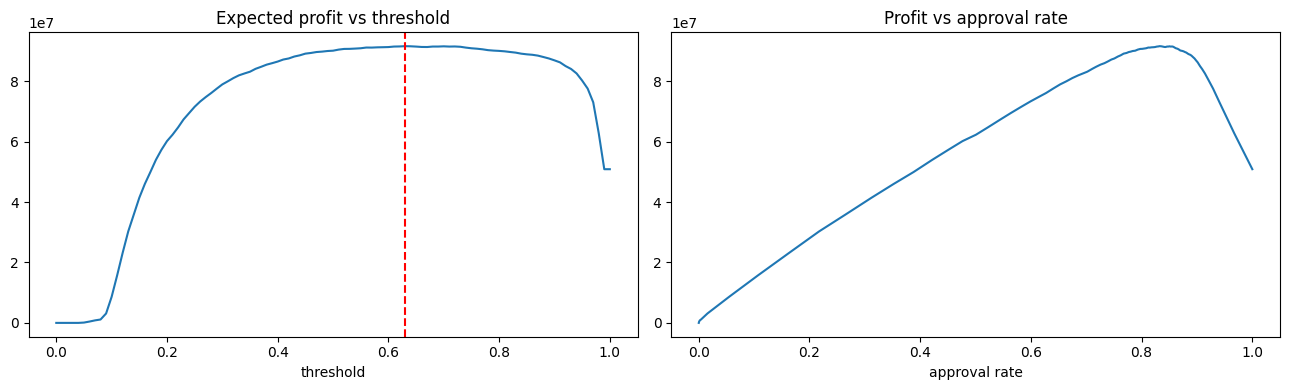

In [4]:
import matplotlib.pyplot as plt
c = opt['curve']
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].plot(c['threshold'], c['profit']); ax[0].axvline(opt['best_threshold'], color='r', ls='--')
ax[0].set_title('Expected profit vs threshold'); ax[0].set_xlabel('threshold')
ax[1].plot(c['approval_rate'], c['profit']); ax[1].set_title('Profit vs approval rate')
ax[1].set_xlabel('approval rate'); plt.tight_layout();

> The profit-max threshold differs from the F1-max threshold — that gap is real money left on the table by accuracy-only thinking.

## Risk-based pricing

In [5]:
priced = X.copy()
priced['default_prob'] = proba.round(3)
priced['suggested_rate'] = profit.risk_based_price(proba, base_rate=0.12)
priced[['loan_amount','salary','default_prob','suggested_rate']].head(10)

,loan_amount,salary,default_prob,suggested_rate
43660,36000.0,3470.959404,0.249,0.3186
87278,29000.0,2562.407601,0.485,0.3200
14317,3000.0,1880.522277,0.081,0.1732
81932,13000.0,2052.096585,0.307,0.3200
95321,44000.0,3268.431681,0.217,0.2859
5405,26000.0,3901.334553,0.541,0.3200
33188,47000.0,3411.314360,0.219,0.2879
63421,33000.0,2358.169247,0.206,0.2752
72897,43000.0,2948.092133,0.109,0.1937
9507,45000.0,2571.064686,0.242,0.3113
